In [1]:
!pip install -q kagglehub pandas numpy scikit-learn matplotlib seaborn joblib transformers datasets accelerate evaluate streamlit pyngrok torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 48.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import kagglehub


In [3]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("rutumane333/ai-vs-human-text-cleaned-and-balanced")

print("Path to dataset files:", path)
print("Files in dataset folder:", os.listdir(path))

Using Colab cache for faster access to the 'ai-vs-human-text-cleaned-and-balanced' dataset.
Path to dataset files: /kaggle/input/ai-vs-human-text-cleaned-and-balanced
Files in dataset folder: ['combined_cleaned.csv']


In [4]:
# Find CSV automatically
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print("CSV files found:", csv_files)

# Load first CSV
df = pd.read_csv(os.path.join(path, csv_files[0]))

print("Dataset Shape:", df.shape)
df.head()

CSV files found: ['combined_cleaned.csv']
Dataset Shape: (437264, 3)


,text,label,word_count
0,"Hey there! For this essay, I had to research d...",1,352
1,You've been at school all day ready to go to w...,0,445
2,I disagree with the principal making all stude...,0,308
3,"In the passage ""The Challenge of Exploring Ven...",0,289
4,Theirs many Other ways to go from One place to...,0,616


In [5]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Dataset Shape: (437264, 3)

Columns: ['text', 'label', 'word_count']


,text,label,word_count
0,"Hey there! For this essay, I had to research d...",1,352
1,You've been at school all day ready to go to w...,0,445
2,I disagree with the principal making all stude...,0,308
3,"In the passage ""The Challenge of Exploring Ven...",0,289
4,Theirs many Other ways to go from One place to...,0,616


In [6]:
print("Columns:", df.columns)
print("\nLabel distribution:")
print(df['label'].value_counts())

Columns: Index(['text', 'label', 'word_count'], dtype='object')

Label distribution:
label
1    218632
0    218632
Name: count, dtype: int64


In [7]:
SAMPLES_PER_CLASS = 5000

# Ensure labels are integers
df['label'] = df['label'].astype(int)

# Balance dataset safely
df = df.groupby('label').sample(n=SAMPLES_PER_CLASS, random_state=42).reset_index(drop=True)

print("Balanced class distribution:")
print(df['label'].value_counts())

Balanced class distribution:
label
0    5000
1    5000
Name: count, dtype: int64


In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)

In [9]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [11]:
ml_model = MultinomialNB(alpha=0.5)
ml_model.fit(X_train, y_train)

MultinomialNB(alpha=0.5)

In [12]:
y_pred = ml_model.predict(X_test)

print("ML Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ML Model Accuracy: 0.929

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1000
           1       0.97      0.88      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



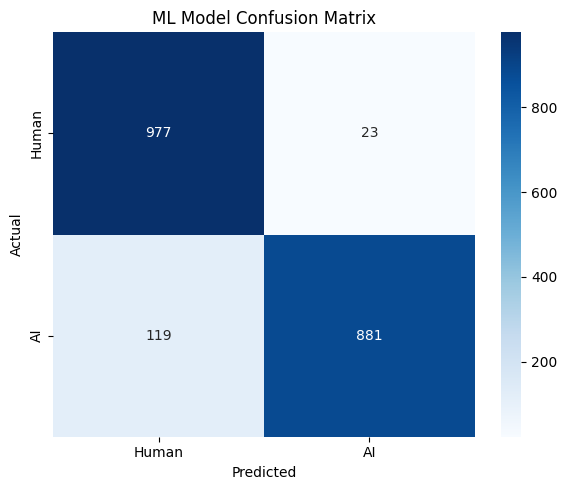

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'])
plt.title("ML Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [14]:
scores = cross_val_score(ml_model, X, y, cv=5, scoring='accuracy')

print("Cross Validation Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

Cross Validation Scores: [0.9275 0.928  0.933  0.9275 0.932 ]
Mean CV Accuracy: 0.9296000000000001


In [15]:
joblib.dump(ml_model, "ml_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("ML model and vectorizer saved.")

ML model and vectorizer saved.


In [16]:
def predict_text_ml(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = ml_model.predict(vec)[0]
    prob = ml_model.predict_proba(vec)[0]
    confidence = np.max(prob)
    label = "AI Generated 🤖" if pred == 1 else "Human Written 👤"
    return f"{label} (confidence: {confidence:.2%})"

In [17]:
samples = [
    "In conclusion, artificial intelligence has revolutionized multiple industries and continues to shape the future.",
    "lol this is crazy",
    "The weather was nice so I just went outside and sat there for a bit.",
    "The implementation of neural architectures has significantly advanced natural language understanding.",
]

print("=" * 60)
print("ML Predictions:")
for s in samples:
    print(f"  [{s[:50]}...] → {predict_text_ml(s)}")


ML Predictions:
  [In conclusion, artificial intelligence has revolut...] → AI Generated 🤖 (confidence: 93.86%)
  [lol this is crazy...] → Human Written 👤 (confidence: 52.10%)
  [The weather was nice so I just went outside and sa...] → Human Written 👤 (confidence: 84.34%)
  [The implementation of neural architectures has sig...] → AI Generated 🤖 (confidence: 96.30%)


In [18]:
import os

if os.path.exists("app.py"):
    os.remove("app.py")
    print("Old app.py deleted")
else:
    print("No old app.py found")

No old app.py found


In [19]:
app_code = """
import streamlit as st
import joblib
import numpy as np
import re

# -----------------------------
# PAGE CONFIG
# -----------------------------
st.set_page_config(
    page_title="AI vs Human Text Detector",
    page_icon="🧠",
    layout="wide"
)

# -----------------------------
# LOAD ML MODEL
# -----------------------------
@st.cache_resource
def load_ml_model():
    model = joblib.load("ml_model.pkl")
    vectorizer = joblib.load("tfidf_vectorizer.pkl")
    return model, vectorizer

ml_model, vectorizer = load_ml_model()

# -----------------------------
# CLEAN TEXT
# -----------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\\s+', ' ', text)
    return text.strip()

# -----------------------------
# ML PREDICTION
# -----------------------------
def predict_text_ml(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])

    pred = ml_model.predict(vec)[0]
    probs = ml_model.predict_proba(vec)[0]
    confidence = np.max(probs)

    ai_prob = probs[1]
    human_prob = probs[0]

    return pred, confidence, ai_prob, human_prob

# -----------------------------
# LABEL MAP
# -----------------------------
def label_map(pred):
    if pred == 1:
        return "Likely AI Generated 🤖"
    else:
        return "Likely Human Written 👤"

# -----------------------------
# SIDEBAR
# -----------------------------
st.sidebar.title("⚙️ Settings")

st.sidebar.markdown("---")
st.sidebar.subheader("📌 Project Info")
st.sidebar.write("**Project:** AI vs Human Text Detector")
st.sidebar.write("**Task:** Binary Text Classification")
st.sidebar.write("**Classes:** AI / Human")

st.sidebar.markdown("---")
st.sidebar.subheader("📊 Model Details")
st.sidebar.write("**Model:** TF-IDF + Naive Bayes")
st.sidebar.write("**Type:** Machine Learning")

# -----------------------------
# MAIN PAGE
# -----------------------------
st.title("🧠 AI vs Human Text Detector")
st.markdown(
    "Enter any text and detect whether it is **AI-generated** or **human-written** using a **Machine Learning model**."
)

user_input = st.text_area(
    "📝 Enter Text Here:",
    height=220,
    placeholder="Paste any paragraph, essay, sentence, or social media text..."
)

if st.button("🔍 Detect Text Source", use_container_width=True):
    if user_input.strip() == "":
        st.warning("Please enter some text first.")
    else:
        pred, conf, ai_prob, human_prob = predict_text_ml(user_input)

        result = label_map(pred)

        st.subheader("🎯 Prediction Result")

        if pred == 1:
            st.error(result)
        else:
            st.success(result)

        st.info(f"Confidence: {conf*100:.2f}%")
        st.write("**Model Used:** TF-IDF + Naive Bayes (ML)")
        st.write(f"**AI Probability:** {ai_prob*100:.2f}%")
        st.write(f"**Human Probability:** {human_prob*100:.2f}%")

        st.progress(int(conf * 100))

# -----------------------------
# EXAMPLES
# -----------------------------
st.markdown("---")
st.subheader("💡 Example Texts")

examples = [
    "In conclusion, artificial intelligence has revolutionized multiple industries and continues to shape the future.",
    "lol this is crazy",
    "The weather was nice so I just went outside and sat there for a bit.",
    "The implementation of neural architectures has significantly advanced natural language understanding."
]

for ex in examples:
    st.code(ex)

# -----------------------------
# MODEL INFO
# -----------------------------
st.markdown("---")
st.subheader("📊 Model Information")

info_table = {
    "Feature": ["Algorithm Type", "Speed", "Context Understanding", "Complexity"],
    "ML Model": ["Traditional ML", "Fast", "Moderate", "Low"]
}

st.table(info_table)

# -----------------------------
# ABOUT
# -----------------------------
st.markdown("---")
st.subheader("📚 About This Project")
st.write(\"\"\"
This project detects whether a text is:
- **AI Generated**
- **Human Written**

Model used:
- **TF-IDF + Naive Bayes**

Useful in:
- academic integrity checks
- content moderation
- writing analysis
- AI text detection systems
\"\"\")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ New ML-only app.py created successfully!")

✅ New ML-only app.py created successfully!


In [20]:
with open("app.py", "r") as f:
    print(f.read())


import streamlit as st
import joblib
import numpy as np
import re

# -----------------------------
# PAGE CONFIG
# -----------------------------
st.set_page_config(
    page_title="AI vs Human Text Detector",
    page_icon="🧠",
    layout="wide"
)

# -----------------------------
# LOAD ML MODEL
# -----------------------------
@st.cache_resource
def load_ml_model():
    model = joblib.load("ml_model.pkl")
    vectorizer = joblib.load("tfidf_vectorizer.pkl")
    return model, vectorizer

ml_model, vectorizer = load_ml_model()

# -----------------------------
# CLEAN TEXT
# -----------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# -----------------------------
# ML PREDICTION
# -----------------------------
def predict_text_ml(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])

    pred = ml_model.predict(vec)[0]
    probs = ml_model.predict_proba(vec)[0]
    confidence = 

In [21]:
!streamlit run app.py &>/content/logs.txt &

In [22]:
!ngrok config add-authtoken 3C11LcOJFPyqGQt0LNrbcA3DelW_2BhPporrXbKw56RUf4FMs

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [23]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://irene-hymnless-dani.ngrok-free.dev" -> "http://localhost:8501"


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
